Importation des bibliothèques

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from tensorflow.keras.callbacks import EarlyStopping

Chargement des données

In [ ]:
train = pd.read_csv('/content/donnees_train.csv')
val = pd.read_csv('/content/donnees_val.csv')
test = pd.read_csv('/content/donnees_test.csv')

Définition des colonnes

In [ ]:
feature_columns = ['VitesseVent (m/s)', 'DirectionVent (°)', 'Temperature (°C)', 'Saison', 'Annee', 'Mois', 'Jour', 'Heure', 'Minute', 'JourNuit', 'deviation', 'deviation_percentage', 'usability']
target_column = "PuissanceActive (kW)"

Filtrage des données

In [ ]:
def filter_df(df):
    return df[(df['VitesseVent (m/s)'] > 3) & (df['VitesseVent (m/s)'] <= 25)].copy()

train_filtered = filter_df(train)
val_filtered = filter_df(val)

Séparation des données par saison

In [ ]:
def split_by_season(df):
    return {
        'hiver': df[df['Saison'] == 1],
        'printemps': df[df['Saison'] == 2],
        'ete': df[df['Saison'] == 3],
        'automne': df[df['Saison'] == 4],
    }

train_seasons = split_by_season(train_filtered)
val_seasons = split_by_season(val_filtered)
test_seasons = split_by_season(test)

Normalisation des données

In [ ]:
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
train_val_filtered = pd.concat([train_filtered, val_filtered])
scaler_X.fit(train_val_filtered[feature_columns])
scaler_y.fit(train_val_filtered[[target_column]])

def scale_df(df):
    df_copy = df.copy()
    df_copy[feature_columns] = df_copy[feature_columns].astype(float)
    df_copy.loc[:, feature_columns] = scaler_X.transform(df_copy[feature_columns])
    df_copy.loc[:, target_column] = scaler_y.transform(df_copy[[target_column]])
    return df_copy

train_filtered_scaled = scale_df(train_filtered)
val_filtered_scaled = scale_df(val_filtered)

Création des séquences

In [ ]:
sequence_length = 96

def create_sequences(df, sequence_length):
    X, y = [], []
    df = df.reset_index(drop=True)
    for i in range(len(df) - sequence_length):
        X_seq = df.iloc[i:i+sequence_length][feature_columns].values
        y_seq = df.iloc[i+sequence_length][target_column]
        X.append(X_seq)
        y.append(y_seq)
    return np.array(X), np.array(y)

Poids personnalisés

In [ ]:
def generate_weights(y_values):
    return np.select(
        [
            y_values < 1000,
            y_values < 8000,
            y_values >= 8000
        ],
        [2.0, 2.0, 14.0]
    )

Séquences d'entraînement

In [ ]:
X_train_seasons, y_train_seasons, w_train_seasons = [], [], []
for season in ['hiver', 'printemps', 'ete', 'automne']:
    scaled_season_df = scale_df(train_seasons[season])
    Xs, ys = create_sequences(scaled_season_df, sequence_length)
    y_real = train_seasons[season][target_column].values[sequence_length:]
    weights = generate_weights(y_real)
    X_train_seasons.append(Xs)
    y_train_seasons.append(ys)
    w_train_seasons.append(weights)

X_train = np.concatenate(X_train_seasons)
y_train = np.concatenate(y_train_seasons)
weights_train = np.concatenate(w_train_seasons)

Séquences de validation

In [ ]:
X_val_seasons, y_val_seasons = [], []
for season in ['hiver', 'printemps', 'ete', 'automne']:
    scaled_season_df = scale_df(val_seasons[season])
    Xs, ys = create_sequences(scaled_season_df, sequence_length)
    X_val_seasons.append(Xs)
    y_val_seasons.append(ys)
X_val = np.concatenate(X_val_seasons)
y_val = np.concatenate(y_val_seasons)

Préparation des données de test

In [ ]:
X_test_seasons = []
y_test_true_seasons = []
for season in ['hiver', 'printemps', 'ete', 'automne']:
    season_df = test_seasons[season].copy()
    season_df[feature_columns] = season_df[feature_columns].astype(float)
    season_df.loc[:, feature_columns] = scaler_X.transform(season_df[feature_columns])
    Xs, ys = create_sequences(season_df, sequence_length)
    X_test_seasons.append(Xs)
    y_test_true_seasons.append(season_df[target_column].values[sequence_length:])

X_test = np.concatenate(X_test_seasons)
y_test_true = np.concatenate(y_test_true_seasons)

Construction et entraînement du modèle

In [ ]:
model = Sequential([
    SimpleRNN(64, input_shape=(sequence_length, len(feature_columns))),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')

early_stop = EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    sample_weight=weights_train,
    validation_data=(X_val, y_val),
    epochs=130,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/130
638/638 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - loss: 0.2877 - val_loss: 0.0066
Epoch 2/130
638/638 ━━━━━━━━━━━━━━━━━━━━ 18s 18ms/step - loss: 0.0279 - val_loss: 0.0041
Epoch 3/130
638/638 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - loss: 0.0204 - val_loss: 0.0033
Epoch 4/130
638/638 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step - loss: 0.0164 - val_loss: 0.0063
Epoch 5/130
638/638 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - loss: 0.0146 - val_loss: 0.0042
Epoch 6/130
638/638 ━━━━━━━━━━━━━━━━━━━━ 22s 19ms/step - loss: 0.0143 - val_loss: 0.0038
Epoch 7/130
638/638 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step - loss: 0.0145 - val_loss: 0.0028
Epoch 8/130
638/638 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - loss: 0.0132 - val_loss: 0.0023
Epoch 9/130
638/638 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - loss: 0.0111 - val_loss: 0.0023
Epoch 10/130
638/638 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - loss: 0.0102 - val_loss: 0.0036
Epoch 11/130
638/638 ━━━━━━━━━━━━━━━━━━━━ 21s 19ms/step - loss: 0.0113 - val_loss: 0.0020
Epoch 12/130
638/63

Courbe d'apprentissage

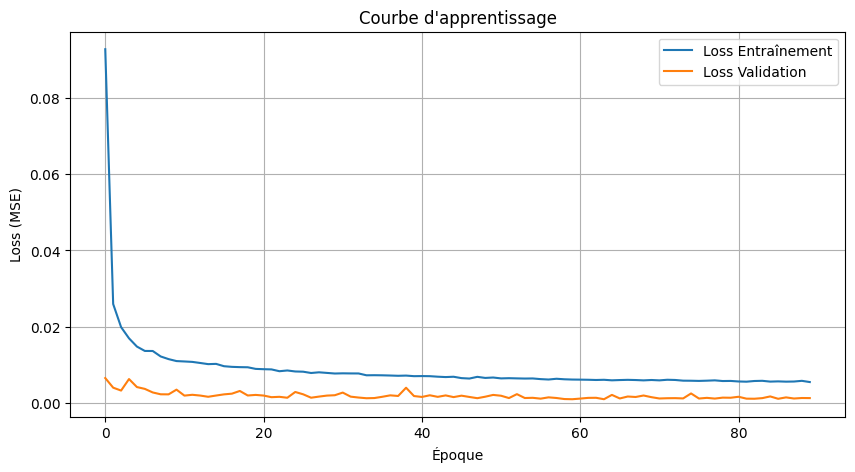

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Loss Entraînement')
plt.plot(history.history['val_loss'], label='Loss Validation')
plt.title("Courbe d'apprentissage")
plt.xlabel("Époque")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(True)
plt.show()

Réentrainement final

In [ ]:
train_val_scaled = scale_df(train_val_filtered)
X_full, y_full = create_sequences(train_val_scaled, sequence_length)
y_real_full = train_val_filtered[target_column].values[sequence_length:]
weights_full = generate_weights(y_real_full)

model_final = Sequential([
    SimpleRNN(64, input_shape=(sequence_length, len(feature_columns))),
    Dense(1, activation='relu')
])
model_final.compile(optimizer='adam', loss='mse')

model_final.fit(
    X_full, y_full,
    sample_weight=weights_full,
    epochs=early_stop.stopped_epoch + 1 if early_stop.stopped_epoch > 0 else 130,
    batch_size=32,
    verbose=1
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/90
732/732 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - loss: 0.1172
Epoch 2/90
732/732 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - loss: 0.0264
Epoch 3/90
732/732 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - loss: 0.0199
Epoch 4/90
732/732 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - loss: 0.0157
Epoch 5/90
732/732 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - loss: 0.0149
Epoch 6/90
732/732 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - loss: 0.0131
Epoch 7/90
732/732 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - loss: 0.0118
Epoch 8/90
732/732 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - loss: 0.0110
Epoch 9/90
732/732 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - loss: 0.0116
Epoch 10/90
732/732 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - loss: 0.0099
Epoch 11/90
732/732 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - loss: 0.0104
Epoch 12/90
732/732 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - loss: 0.0099
Epoch 13/90
732/732 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - loss: 0.0095
Epoch 14/90
732/732 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - loss: 0.0091
Epoch 15/90
732/732 ━━━━━━━━━

Prédictions

In [ ]:
y_pred_scaled = model_final.predict(X_test).flatten()
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

vent_test_values = []
for season in ['hiver', 'printemps', 'ete', 'automne']:
    vent_vals = test_seasons[season]['VitesseVent (m/s)'].values
    vents_seq = vent_vals[sequence_length:]
    vent_test_values.append(vents_seq)

vent_test_concat = np.concatenate(vent_test_values)
mask_valid_vent = (vent_test_concat > 3) & (vent_test_concat <= 25)
y_pred_masked = np.where(mask_valid_vent, y_pred, 0)

202/202 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step


Évaluation par plage

avec mask

In [ ]:
y_test_used = y_test_true[mask_valid_vent] / 1000
y_pred_used = y_pred_masked[mask_valid_vent] / 1000

mse = mean_squared_error(y_test_used, y_pred_used)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_used, y_pred_used)
r2 = r2_score(y_test_used, y_pred_used)
mape = np.mean(np.abs((y_test_used - y_pred_used) / y_test_used.clip(min=1e-8))) * 100
smape = 100 * np.mean(
    2 * np.abs(y_pred_used - y_test_used) / (np.abs(y_test_used) + np.abs(y_pred_used) + 1e-8)
)
range_y = np.max(y_test_used) - np.min(y_test_used)
nrmse_range = (rmse / range_y) * 100 if range_y > 0 else float("inf")
nmse_range = (mse / (range_y ** 2)) * 100 if range_y > 0 else float("inf")
nmae = (mae / range_y) * 100 if range_y > 0 else float("inf")

print("Évaluation sur test filtré uniquement (VitesseVent > 3 et <= 25 m/s) :")
print(f" - MSE   : {mse:.4f}MW²")
print(f" - RMSE  : {rmse:.4f}MW")
print(f" - MAE   : {mae:.4f}MW")
print(f" - R2    : {r2:.4f}")
print(f" - MAPE  : {mape:.4f}%")
print(f" - SMAPE  : {smape:.4f}%")
print(f" - NRMSE : {nrmse_range:.4f}%")
print(f" - NMSE  : {nmse_range:.4f}%")
print(f" - NMAE   : {nmae:.4f}%")

Évaluation sur test filtré uniquement (VitesseVent > 3 et <= 25 m/s) :
 - MSE   : 0.0775MW²
 - RMSE  : 0.2784MW
 - MAE   : 0.1776MW
 - R2    : 0.9792
 - MAPE  : 18.7277%
 - SMAPE  : 18.4801%
 - NRMSE : 2.7446%
 - NMSE  : 0.0753%
 - NMAE   : 1.7510%


sur lenssemble de test

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Conversion des valeurs de kW en MW
y_test_true_MW = y_test_true / 1000
y_pred_masked_MW = y_pred_masked / 1000

mse = mean_squared_error(y_test_true_MW, y_pred_masked_MW)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_true_MW, y_pred_masked_MW)
r2 = r2_score(y_test_true_MW, y_pred_masked_MW)
mape = np.mean(np.abs((y_test_true_MW - y_pred_masked_MW) / y_test_true_MW.clip(min=1e-8))) * 100
range_y = np.max(y_test_true_MW) - np.min(y_test_true_MW)
nrmse_range = (rmse / range_y) * 100
nmse_range = (mse / (range_y ** 2)) * 100
smape = np.mean(2 * np.abs(y_pred_masked_MW - y_test_true_MW) / (np.abs(y_test_true_MW) + np.abs(y_pred_masked_MW)).clip(min=1e-8)) * 100
nmae = (mae / range_y) * 100

print("Évaluation sur le jeu de test (en MW) :")
print(f" - MSE           : {mse:.4f}MW²")
print(f" - RMSE          : {rmse:.4f}MW")
print(f" - MAE           : {mae:.4f}MW")
print(f" - R2            : {r2:.4f}")
print(f" - MAPE          : {mape:.4f}%")
print(f" - SMAPE         : {smape:.4f}%")
print(f" - NMSE          : {nmse_range:.4f}%")
print(f" - NRMSE         : {nrmse_range:.4f}%")
print(f" - NMAE          : {nmae:.4f}%")

Évaluation sur le jeu de test (en MW) :
 - MSE           : 0.0755MW²
 - RMSE          : 0.2747MW
 - MAE           : 0.1801MW
 - R2            : 0.9789
 - MAPE          : 23.1090%
 - SMAPE         : 18.6191%
 - NMSE          : 0.0725%
 - NRMSE         : 2.6934%
 - NMAE          : 1.7655%


Graphique prédictions vs réelles

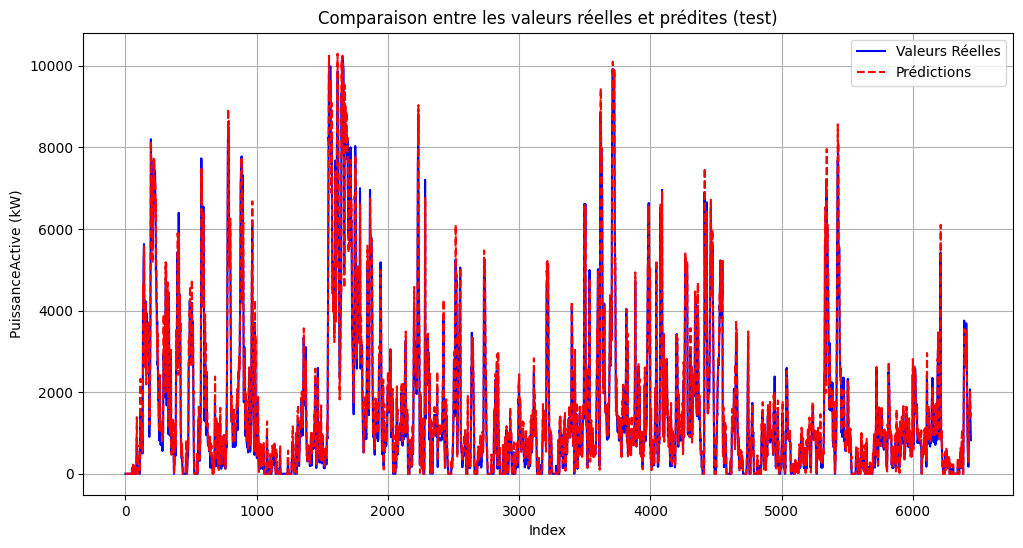

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(y_test_true, label='Valeurs Réelles', color='blue')
plt.plot(y_pred_masked, label='Prédictions', color='red', linestyle='--')
plt.title("Comparaison entre les valeurs réelles et prédites (test)")
plt.xlabel("Index")
plt.ylabel("PuissanceActive (kW)")
plt.legend()
plt.grid(True)
plt.show()

Évaluation par plage

avec mask

In [2]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def eval_par_plage_avec_vent(y_true, y_pred, plage_name, mask_plage, mask_vent):
    # Masque combiné : plage et vent valide
    mask_total = mask_plage & mask_vent

    y_true_plage = y_true[mask_total] / 1000  # kW → MW
    y_pred_plage = y_pred[mask_total] / 1000  # kW → MW

    if len(y_true_plage) == 0:
        print(f"\nAucune donnée valide (vent + plage) dans la plage '{plage_name}'.")
        return

    # Calcul des métriques
    mse_p = mean_squared_error(y_true_plage, y_pred_plage)
    rmse_p = np.sqrt(mse_p)
    mae_p = mean_absolute_error(y_true_plage, y_pred_plage)
    r2_p = r2_score(y_true_plage, y_pred_plage)
    mape_p = np.mean(np.abs((y_true_plage - y_pred_plage) / y_true_plage.clip(min=1e-8))) * 100
    smape_p = np.mean(2 * np.abs(y_pred_plage - y_true_plage) /
                      (np.abs(y_true_plage) + np.abs(y_pred_plage)).clip(min=1e-8)) * 100
    global_range_y_test_MW = (np.max(y_true_plage) - np.min(y_true_plage))
    nrmse_range = (rmse_p / global_range_y_test_MW) * 100 if global_range_y_test_MW > 0 else float('inf')
    nmse_range = (mse_p / (global_range_y_test_MW ** 2)) * 100 if global_range_y_test_MW > 0 else float('inf')
    nmae_p = (mae_p / global_range_y_test_MW) * 100 if global_range_y_test_MW > 0 else float('inf')

    print(f"\nÉvaluation pour la plage '{plage_name}' :")
    print(f" - MSE                : {mse_p:.4f} MW²")
    print(f" - RMSE               : {rmse_p:.4f} MW")
    print(f" - MAE                : {mae_p:.4f} MW")
    print(f" - R2                 : {r2_p:.4f}")
    print(f" - MAPE               : {mape_p:.4f} %")
    print(f" - SMAPE              : {smape_p:.4f} %")
    print(f" - NMSE               : {nmse_range:.4f} %")
    print(f" - NRMSE              : {nrmse_range:.4f} %")
    print(f" - NMAE               : {nmae_p:.4f} %")

# Concaténation des vraies valeurs pour les masques
y_test_true_concat_unprocessed = []
for season in ['hiver', 'printemps', 'ete', 'automne']:
    y_true_season_unprocessed = test_seasons[season][target_column].values[sequence_length:]
    y_test_true_concat_unprocessed.append(y_true_season_unprocessed)

y_test_true_aligned_for_masking = np.concatenate(y_test_true_concat_unprocessed)

# Creation du masque des données valides selon le vent, aligné avec les prédictions et les vraies valeurs
vent_test_values_aligned = []
for season in ['hiver', 'printemps', 'ete', 'automne']:
    vent_vals = test_seasons[season]['VitesseVent (m/s)'].values
    vents_seq = vent_vals[sequence_length:]
    vent_test_values_aligned.append(vents_seq)

vent_test_concat_aligned = np.concatenate(vent_test_values_aligned)
mask_vent_aligned = (vent_test_concat_aligned > 3) & (vent_test_concat_aligned <= 25)


# Masques par plage
mask_basse_aligned = y_test_true_aligned_for_masking < 1000
mask_moyenne_aligned = (y_test_true_aligned_for_masking >= 1000) & (y_test_true_aligned_for_masking < 8000)
mask_haute_aligned = y_test_true_aligned_for_masking >= 8000

# Évaluations par plage
eval_par_plage_avec_vent(y_test_true_aligned_for_masking, y_pred_masked, "Basse production (<1000)", mask_basse_aligned, mask_vent_aligned)
eval_par_plage_avec_vent(y_test_true_aligned_for_masking, y_pred_masked, "Moyenne production (1000-8000)", mask_moyenne_aligned, mask_vent_aligned)
eval_par_plage_avec_vent(y_test_true_aligned_for_masking, y_pred_masked, "Haute production (>=8000)", mask_haute_aligned, mask_vent_aligned)


Évaluation pour la plage 'Basse production (<1000)' :
 - MSE                : 0.0403MW²
 - RMSE               : 0.2008MW
 - MAE                : 0.1559MW
 - R2                 : 0.4874
 - MAPE               : 40.3626%
 - SMAPE              : 31.2849%
 - NMSE               : 4.5369%
 - NRMSE              : 21.3001%
 - NMAE               : 16.5345%

Évaluation pour la plage 'Moyenne production (1000-8000)' :
 - MSE                : 0.1364MW²
 - RMSE               : 0.3694MW
 - MAE                : 0.2649MW
 - R2                 : 0.9560
 - MAPE               : 11.5981%
 - SMAPE              : 10.7486%
 - NMSE               : 0.2785%
 - NRMSE              : 5.2774%
 - NMAE               : 3.7843%

Évaluation pour la plage 'Haute production (>=8000)' :
 - MSE                : 0.2941MW²
 - RMSE               : 0.5424MW
 - MAE                : 0.4377MW
 - R2                 : 0.4603
 - MAPE               : 4.9636%
 - SMAPE              : 4.8707%
 - NMSE               : 6.2545%
 - NRMSE     

sur lensemble des donnes de test

In [3]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def eval_par_plage(y_true, y_pred, plage_name, mask):
    y_true_plage = y_true[mask] / 1000  # conversion kW → MW
    y_pred_plage = y_pred[mask] / 1000  # conversion kW → MW

    if len(y_true_plage) == 0:
        print(f"\nAucune donnée dans la plage '{plage_name}'.")
        return

    # Calcul des métriques
    mse_p = mean_squared_error(y_true_plage, y_pred_plage)
    rmse_p = np.sqrt(mse_p)
    mae_p = mean_absolute_error(y_true_plage, y_pred_plage)
    r2_p = r2_score(y_true_plage, y_pred_plage)
    mape_p = np.mean(np.abs((y_true_plage - y_pred_plage) / y_true_plage.clip(min=1e-8))) * 100
    smape_p = np.mean(2 * np.abs(y_pred_plage - y_true_plage) /
                      (np.abs(y_true_plage) + np.abs(y_pred_plage)).clip(min=1e-8)) * 100
    global_range_y_test_MW = (np.max(y_true_plage) - np.min(y_true_plage))
    nrmse_range = (rmse_p / global_range_y_test_MW) * 100 if global_range_y_test_MW > 0 else float('inf')
    nmse_range = (mse_p / (global_range_y_test_MW ** 2)) * 100 if global_range_y_test_MW > 0 else float('inf')
    nmae_p = (mae_p / global_range_y_test_MW) * 100 if global_range_y_test_MW > 0 else float('inf')

    # Affichage des résultats
    print(f"\nÉvaluation pour la plage '{plage_name}' :")
    print(f" - MSE                : {mse_p:.6f}MW²")
    print(f" - RMSE               : {rmse_p:.6f}MW")
    print(f" - MAE                : {mae_p:.6f}MW")
    print(f" - R2                 : {r2_p:.6f}")
    print(f" - MAPE               : {mape_p:.6f}%")
    print(f" - SMAPE              : {smape_p:.6f}%")
    print(f" - NMSE               : {nmse_range:.6f}%")
    print(f" - NRMSE              : {nrmse_range:.6f}%")
    print(f" - NMAE               : {nmae_p:.6f}%")

# Concaténation des vraies valeurs pour les masques
y_test_true_concat_unprocessed = []
for season in ['hiver', 'printemps', 'ete', 'automne']:
    y_true_season_unprocessed = test_seasons[season][target_column].values[sequence_length:]
    y_test_true_concat_unprocessed.append(y_true_season_unprocessed)

y_test_true_aligned_for_masking = np.concatenate(y_test_true_concat_unprocessed)

# Création des masques
mask_basse_aligned = y_test_true_aligned_for_masking < 1000
mask_moyenne_aligned = (y_test_true_aligned_for_masking >= 1000) & (y_test_true_aligned_for_masking < 8000)
mask_haute_aligned = y_test_true_aligned_for_masking >= 8000

# Évaluations par plage
eval_par_plage(y_test_true, y_pred_masked, 'Basse production (<1000)', mask_basse_aligned)
eval_par_plage(y_test_true, y_pred_masked, 'Moyenne production (1000-8000)', mask_moyenne_aligned)
eval_par_plage(y_test_true, y_pred_masked, 'Haute production (>=8000)', mask_haute_aligned)


Évaluation pour la plage 'Basse production (<1000)' :
 - MSE                : 0.030862MW²
 - RMSE               : 0.175677MW
 - MAE                : 0.119300MW
 - R2                 : 0.737242
 - MAPE               : 30.904135%
 - SMAPE              : 23.985332%
 - NMSE               : 3.094214%
 - NRMSE              : 17.590378%
 - NMAE               : 11.945417%

Évaluation pour la plage 'Moyenne production (1000-8000)' :
 - MSE                : 0.136444MW²
 - RMSE               : 0.369384MW
 - MAE                : 0.264872MW
 - R2                 : 0.956043
 - MAPE               : 11.598125%
 - SMAPE              : 10.748621%
 - NMSE               : 0.278513%
 - NRMSE              : 5.277432%
 - NMAE               : 3.784256%

Évaluation pour la plage 'Haute production (>=8000)' :
 - MSE                : 0.294150MW²
 - RMSE               : 0.542356MW
 - MAE                : 0.437660MW
 - R2                 : 0.460335
 - MAPE               : 4.963648%
 - SMAPE              : 4.87070

Prédiction sur les dernières 24h (96 pas de 15 minutes)

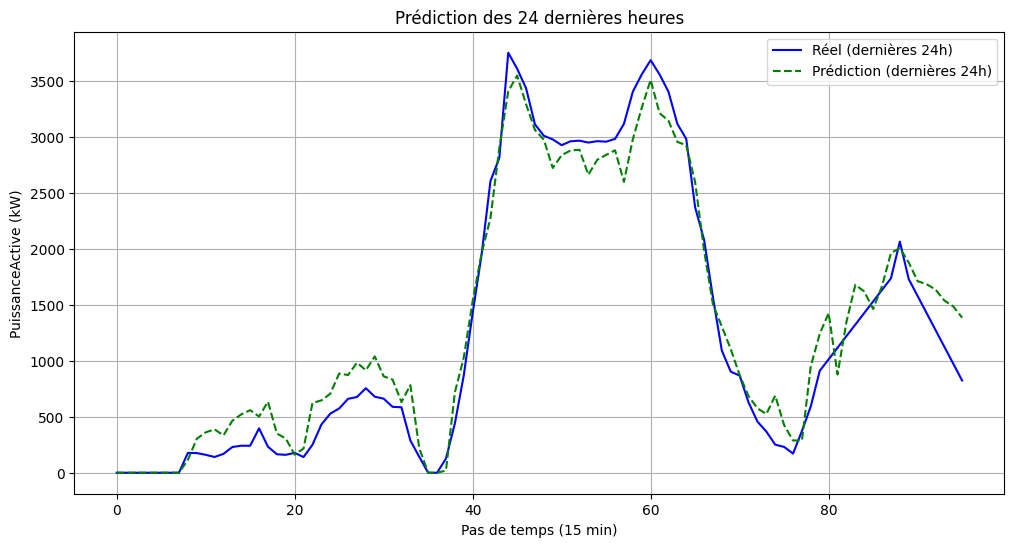

In [ ]:
y_last_24h_true = y_test_true[-sequence_length:]
y_last_24h_pred = y_pred_masked[-sequence_length:]

plt.figure(figsize=(12, 6))
plt.plot(y_last_24h_true, label='Réel (dernières 24h)', color='blue')
plt.plot(y_last_24h_pred, label='Prédiction (dernières 24h)', color='green', linestyle='--')
plt.title("Prédiction des 24 dernières heures")
plt.xlabel("Pas de temps (15 min)")
plt.ylabel("PuissanceActive (kW)")
plt.legend()
plt.grid(True)
plt.show()

Sauvegarde et téléchargement du modèle et des prédictions

In [ ]:
model.save("/content/rnn_model.h5")
np.save("/content/predictions_rnn.npy", y_pred_masked)
print("Modèle et prédictions sauvegardés !")

from google.colab import files
files.download("/content/rnn_model.h5")
files.download("/content/predictions_rnn.npy")

Modèle et prédictions sauvegardés !


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>